In [1]:
import copy
from pathlib import Path

import requests
from IPython.display import display
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import mdtraj as md
import pdbfixer
import openmm as mm
import openmm.app as app
from openmm import unit
from openff.toolkit.topology import Molecule, Topology
from openmmforcefields.generators import GAFFTemplateGenerator

/home/mk-avid-workstation/miniforge3/envs/MD_science/lib/python3.10/site-packages/pdbfixer/pdbfixer.py:58: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
# create data directory if not exists
HERE = Path(_dh[-1])
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)

In [3]:
pdbid = "3FHD"
#ligand_name = "03P"
pdb_path = DATA / f"{pdbid}.pdb"
pdb_url = f"https://files.rcsb.org/download/{pdbid}.pdb"

In [4]:
r = requests.get(pdb_url)
r.raise_for_status()
with open(pdb_path, "wb") as f:
    f.write(r.content)

In [5]:
def prepare_protein(
    pdb_file, ignore_missing_residues=True, ignore_terminal_missing_residues=True, ph=7.0
):
    """
    Use pdbfixer to prepare the protein from a PDB file. Hetero atoms such as ligands are
    removed and non-standard residues replaced. Missing atoms to existing residues are added.
    Missing residues are ignored by default, but can be included.

    Parameters
    ----------
    pdb_file: pathlib.Path or str
        PDB file containing the system to simulate.
    ignore_missing_residues: bool, optional
        If missing residues should be ignored or built.
    ignore_terminal_missing_residues: bool, optional
        If missing residues at the beginning and the end of a chain should be ignored or built.
    ph: float, optional
        pH value used to determine protonation state of residues

    Returns
    -------
    fixer: pdbfixer.pdbfixer.PDBFixer
        Prepared protein system.
    """
    fixer = pdbfixer.PDBFixer(str(pdb_file))
    fixer.removeHeterogens()  # co-crystallized ligands are unknown to PDBFixer
    fixer.findMissingResidues()  # identify missing residues, needed for identification of missing atoms

    # if missing terminal residues shall be ignored, remove them from the dictionary
    if ignore_terminal_missing_residues:
        chains = list(fixer.topology.chains())
        keys = fixer.missingResidues.keys()
        for key in list(keys):
            chain = chains[key[0]]
            if key[1] == 0 or key[1] == len(list(chain.residues())):
                del fixer.missingResidues[key]

    # if all missing residues shall be ignored ignored, clear the dictionary
    if ignore_missing_residues:
        fixer.missingResidues = {}

    fixer.findNonstandardResidues()  # find non-standard residue
    fixer.replaceNonstandardResidues()  # replace non-standard residues with standard one
    fixer.findMissingAtoms()  # find missing heavy atoms
    fixer.addMissingAtoms()  # add missing atoms and residues
    fixer.addMissingHydrogens(ph)  # add missing hydrogens
    return fixer

In [6]:
# prepare protein and build only missing non-terminal residues
prepared_protein = prepare_protein(pdb_path, ignore_missing_residues=False)

In [7]:
def merge_protein_and_ligand(protein):
    """
    Merge two OpenMM objects.

    Parameters
    ----------
    protein: pdbfixer.pdbfixer.PDBFixer
        Protein to merge.
    ligand: openmm.app.Modeller
        Ligand to merge.

    Returns
    -------
    complex_topology: openmm.app.topology.Topology
        The merged topology.
    complex_positions: openmm.unit.quantity.Quantity
        The merged positions.
    """
    # combine topologies
    md_protein_topology = md.Topology.from_openmm(protein.topology)  # using mdtraj for protein top
    # md_ligand_topology = md.Topology.from_openmm(ligand.topology)  # using mdtraj for ligand top
    md_complex_topology = md_protein_topology
    complex_topology = md_complex_topology.to_openmm()

    # combine positions
    total_atoms = len(protein.positions)

    # create an array for storing all atom positions as tupels containing a value and a unit
    # called OpenMM Quantities
    complex_positions = unit.Quantity(np.zeros([total_atoms, 3]), unit=unit.nanometers)
    complex_positions[: len(protein.positions)] = protein.positions  # add protein positions
    # complex_positions[len(protein.positions) :] = ligand.positions  # add ligand positions

    return complex_topology, complex_positions

In [8]:
complex_topology, complex_positions = merge_protein_and_ligand(prepared_protein)

In [9]:
print("Complex topology has", complex_topology.getNumAtoms(), "atoms.")
# NBVAL_CHECK_OUTPUT

Complex topology has 8201 atoms.


In [10]:
def generate_forcefield(
    rdkit_mol=None, protein_ff="amber14-all.xml", solvent_ff="amber14/tip3pfb.xml"
):
    """
    Generate an OpenMM Forcefield object and register a small molecule.

    Parameters
    ----------
    rdkit_mol: rdkit.Chem.rdchem.Mol
        Small molecule to register in the force field.
    protein_ff: string
        Name of the force field.
    solvent_ff: string
        Name of the solvent force field.

    Returns
    -------
    forcefield: openmm.app.Forcefield
        Forcefield with registered small molecule.
    """
    forcefield = app.ForceField(protein_ff, solvent_ff)

    if rdkit_mol is not None:
        gaff = GAFFTemplateGenerator(
            molecules=Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True)
        )
        forcefield.registerTemplateGenerator(gaff.generator)

    return forcefield

In [11]:
forcefield = generate_forcefield(rdkit_mol=None)

In [12]:
modeller = app.Modeller(complex_topology, complex_positions)
modeller.addSolvent(forcefield, padding=1.0 * unit.nanometers, ionicStrength=0.15 * unit.molar)

In [13]:
system = forcefield.createSystem(modeller.topology, nonbondedMethod=app.PME)
integrator = mm.LangevinIntegrator(
    300 * unit.kelvin, 1.0 / unit.picoseconds, 2.0 * unit.femtoseconds
)
simulation = app.Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

In [14]:
simulation.minimizeEnergy()
with open(DATA / "topology.pdb", "w") as pdb_file:
    app.PDBFile.writeFile(
        simulation.topology,
        simulation.context.getState(getPositions=True, enforcePeriodicBox=True).getPositions(),
        file=pdb_file,
        keepIds=True,
    )

In [15]:
# output settings
import sys
steps = 25000000         # 1,000 ps = 1 ns (A good initial test run)
write_interval = 50000   # Save coordinates every 10 ps
log_interval = 10000     # Print status to screen every 2 ps

simulation.reporters.append(
        md.reporters.XTCReporter(file=str(DATA / "trajectory.xtc"), reportInterval=write_interval)
)
simulation.reporters.append(
    app.StateDataReporter(
        sys.stdout,
        log_interval,
        step=True,
        potentialEnergy=True,
        temperature=True,
        progress=True,
        remainingTime=True,
        speed=True,
        totalSteps=steps,
        separator="\t",
    )
)

In [16]:
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin)
simulation.step(steps)  # perform the simulation

#"Progress (%)"	"Step"	"Potential Energy (kJ/mole)"	"Temperature (K)"	"Speed (ns/day)"	"Time Remaining"
0.0%	10000	-1399148.632893256	300.11177814991146	0	--
0.1%	20000	-1402872.0987135684	298.6499180884807	397	3:01:20
0.1%	30000	-1398518.7432448184	301.4073195209025	397	3:01:20
0.2%	40000	-1401029.3760573184	299.62849919361344	396	3:01:29
0.2%	50000	-1401825.8330885684	300.2195564821407	396	3:01:25
0.2%	60000	-1402079.7979323184	299.9980626340651	396	3:01:22
0.3%	70000	-1401605.6905104434	299.00325076488315	396	3:01:19
0.3%	80000	-1400354.964924506	300.85712639407956	396	3:01:17
0.4%	90000	-1402147.5069166934	298.0547236664764	396	3:01:16
0.4%	100000	-1400538.834065131	299.53132301193983	396	3:01:13
0.4%	110000	-1402931.3428541934	297.3760626052514	396	3:01:11
0.5%	120000	-1401679.545002631	300.0463556878717	395	3:01:10
0.5%	130000	-1401861.898518256	300.0531843536666	395	3:01:06
0.6%	140000	-1402332.349690131	300.82575906150487	396	3:00:59
0.6%	150000	-1400832.621174506	300.453615350

In [17]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nglview as nv
import MDAnalysis as mda
from MDAnalysis.analysis import rms, diffusionmap, align
from MDAnalysis.analysis.distances import dist
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [18]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [19]:
md_universe = mda.Universe(str(DATA / "topology.pdb"), str(DATA / "trajectory.xtc"))
view = nv.show_mdanalysis(md_universe)
view

/home/mk-avid-workstation/miniforge3/envs/MD_science/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:295: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "


NGLWidget(max_frame=499)

In [20]:
view.render_image(trim=True, factor=2, transparent=True);

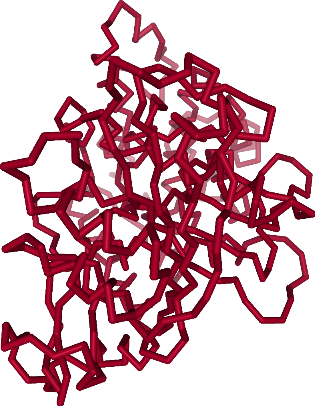

In [21]:
view._display_image()

In [23]:
def rmsd_for_atomgroups(universe, selection1, selection2=None):
    """Calculate the RMSD for selected atom groups.

    Parameters
    ----------
    universe: MDAnalysis.core.universe.Universe
        MDAnalysis universe.
    selection1: str
        Selection string for main atom group, also used during alignment.
    selection2: list of str, optional
        Selection strings for additional atom groups.
        # For protein-only: pass None or omit this argument entirely.
        # To re-enable ligand: pass ["resname 03P"] here.

    Returns
    -------
    rmsd_df: pandas.core.frame.DataFrame
        DataFrame containing RMSD of the selected atom groups over time.
    """

    universe.trajectory[0]
    ref = universe
    rmsd_analysis = rms.RMSD(
        universe,
        ref,
        select=selection1,
        groupselections=selection2,  # None for protein-only; add ligand selections here if needed
    )
    rmsd_analysis.run()

    columns = [selection1, *selection2] if selection2 else [selection1]
    rmsd_df = pd.DataFrame(
        np.round(rmsd_analysis.results.rmsd[:, 2:], 2),
        columns=columns
    )
    rmsd_df.index.name = "frame"
    return rmsd_df

In [24]:
rmsd = rmsd_for_atomgroups(md_universe, "backbone", ["protein"])
# selection2=["resname 03P"]  # ligand — uncomment if ligand present
rmsd.head()


,backbone,protein
frame,,
0,0.00,0.00
1,0.87,1.26
2,1.08,1.47
3,1.20,1.65
4,1.24,1.67


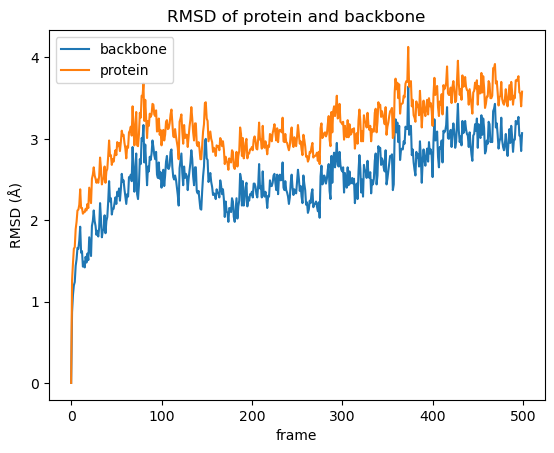

In [26]:
rmsd.plot(title="RMSD of protein and backbone")
plt.ylabel("RMSD (Å)");

In [27]:
def RMSD_dist_frames(universe, selection):
    """Calculate the RMSD between all frames in a matrix.

    Parameters
    ----------
    universe: MDAnalysis.core.universe.Universe
        MDAnalysis universe.
    selection: str
        Selection string for the atomgroup to be investigated, also used during alignment.

    Returns
    -------
    array: np.ndarray
        Numpy array of RMSD values.
    """
    pairwise_rmsd = diffusionmap.DistanceMatrix(universe, select=selection)
    pairwise_rmsd.run()
    return pairwise_rmsd.results.dist_matrix

In [28]:
dist_matrix_protein = RMSD_dist_frames(md_universe, "protein")
# dist_matrix_ligand = RMSD_dist_frames(md_universe, f"resname {ligand_name}")

In [30]:
# get maximal distance between all frames
max_dist = np.amax(dist_matrix_protein)

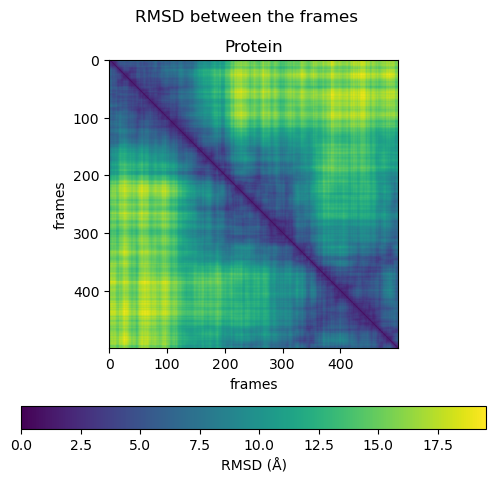

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))  # single plot, no ligand
fig.suptitle("RMSD between the frames")

# protein image
img1 = ax.imshow(dist_matrix_protein, cmap="viridis", vmin=0, vmax=max_dist)
ax.title.set_text("Protein")
ax.set_xlabel("frames")
ax.set_ylabel("frames")

# # ligand image — uncomment if ligand present
# img2 = ax[1].imshow(dist_matrix_ligand, cmap="viridis", vmin=0, vmax=max_dist)
# ax[1].title.set_text("Ligand")
# ax[1].set_xlabel("frames")

fig.colorbar(img1, ax=ax, orientation="horizontal", fraction=0.1, label="RMSD (Å)")
